In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!rm -rf DrumRecognizer
!git clone https://github.com/DongHaShin03/DrumRecognizer.git

Cloning into 'DrumRecognizer'...
remote: Enumerating objects: 200, done.
remote: Counting objects: 100% (58/58), done.
remote: Compressing objects: 100% (58/58), done.
remote: Total 200 (delta 6), reused 43 (delta 0), pack-reused 142 (from 1)
Receiving objects: 100% (200/200), 66.92 MiB | 24.14 MiB/s, done.
Resolving deltas: 100% (13/13), done.


In [ ]:
df = pd.read_csv("/content/DrumRecognizer/drum_features.csv")


#**Statistical Analysis**


In [ ]:
df.describe()

,zcr,cent,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10
count,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000
mean,0.109402,2163.926106,-418.989451,34.444015,1.302491,21.824587,-0.497447,6.936368,0.967515,2.569571,-1.022867,2.556202
std,0.121778,1171.428072,121.748999,23.517506,32.161000,13.642177,20.772419,11.386541,13.529159,9.670983,9.862486,6.919639
min,0.005410,371.681161,-546.771362,-47.272068,-96.540817,-31.095238,-51.832325,-22.389727,-29.527975,-23.975317,-32.969414,-14.111589
25%,0.020549,1243.042101,-494.744949,24.100955,-4.444225,12.986373,-10.558614,-0.197558,-8.085452,-3.992760,-7.683738,-2.720391
50%,0.042640,1716.023101,-470.242661,36.359591,12.700473,22.343081,5.477486,8.779316,1.240363,1.982047,-2.036100,1.693221
75%,0.211879,3192.893860,-410.893166,49.807302,22.261728,29.705428,15.648708,14.650237,11.157477,9.952284,7.090042,7.399133
max,0.463340,5433.475395,-103.349304,86.414696,51.606239,65.479881,38.687157,35.202164,27.963320,22.447306,19.033140,22.401976


In [ ]:
cat_vars = ["label"]
num_vars = ["zcr", "cent"]
n_mfcc = 10
for i in range(n_mfcc):
  num_vars.append(f"mfcc_{i+1}")


##**Histogram**


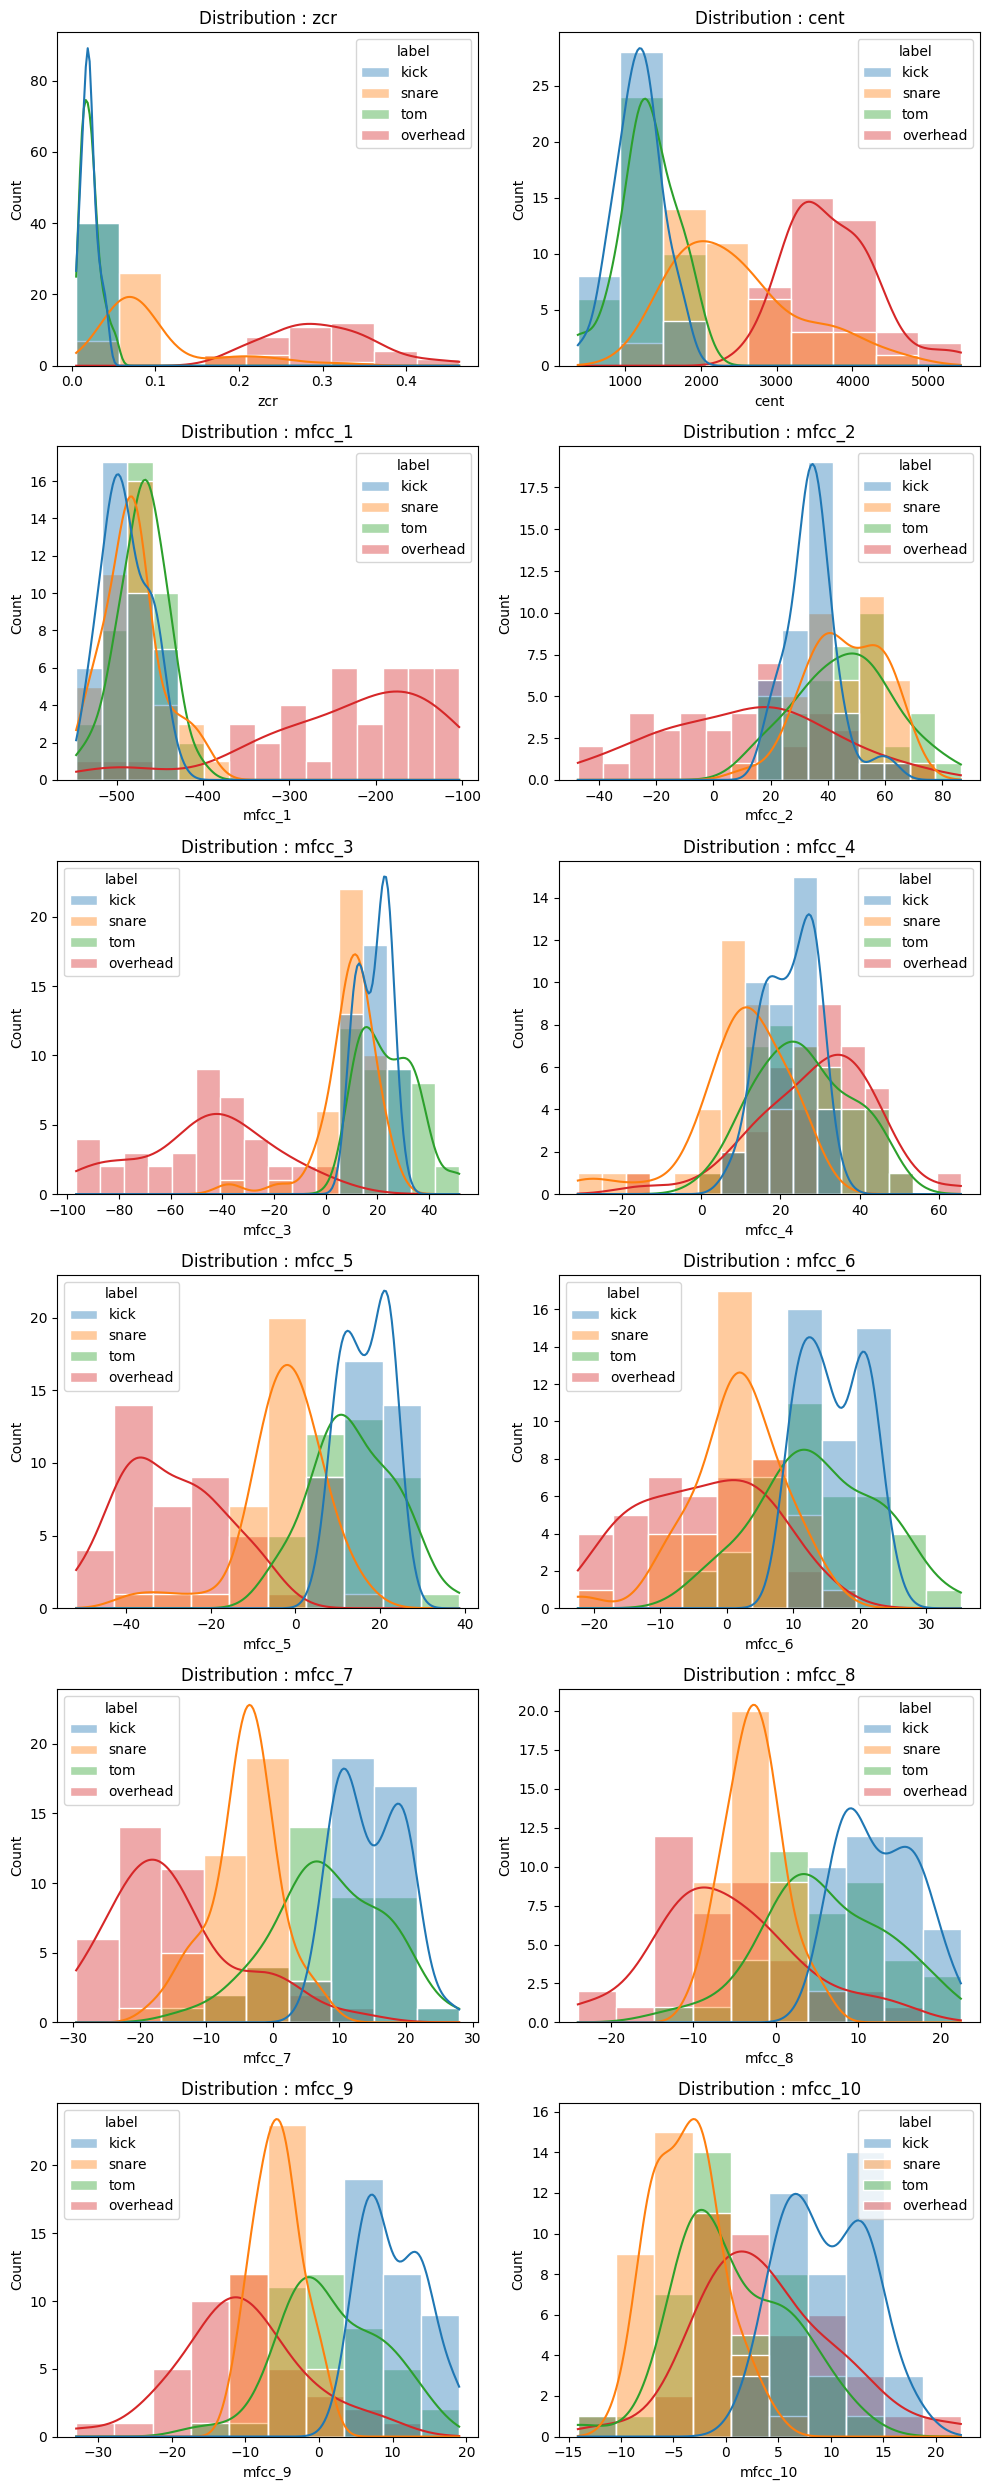

In [ ]:
nrows = 6
ncols = 2

fig, ax = plt.subplots(nrows=nrows, ncols=ncols,figsize = (10,25))
for i in range(len(num_vars)):
    plt.subplot(nrows, ncols, i+1)
    sns.histplot(
      data=df, x=num_vars[i], kde=True,
      alpha=.4, edgecolor=(1, 1, 1),
      hue = "label"
    )
    title = 'Distribution : ' + num_vars[i]
    plt.title(title)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/2 - Side Projects/DrumRecognizer/imgs/histplot.png')
plt.show()

##**Boxplot**

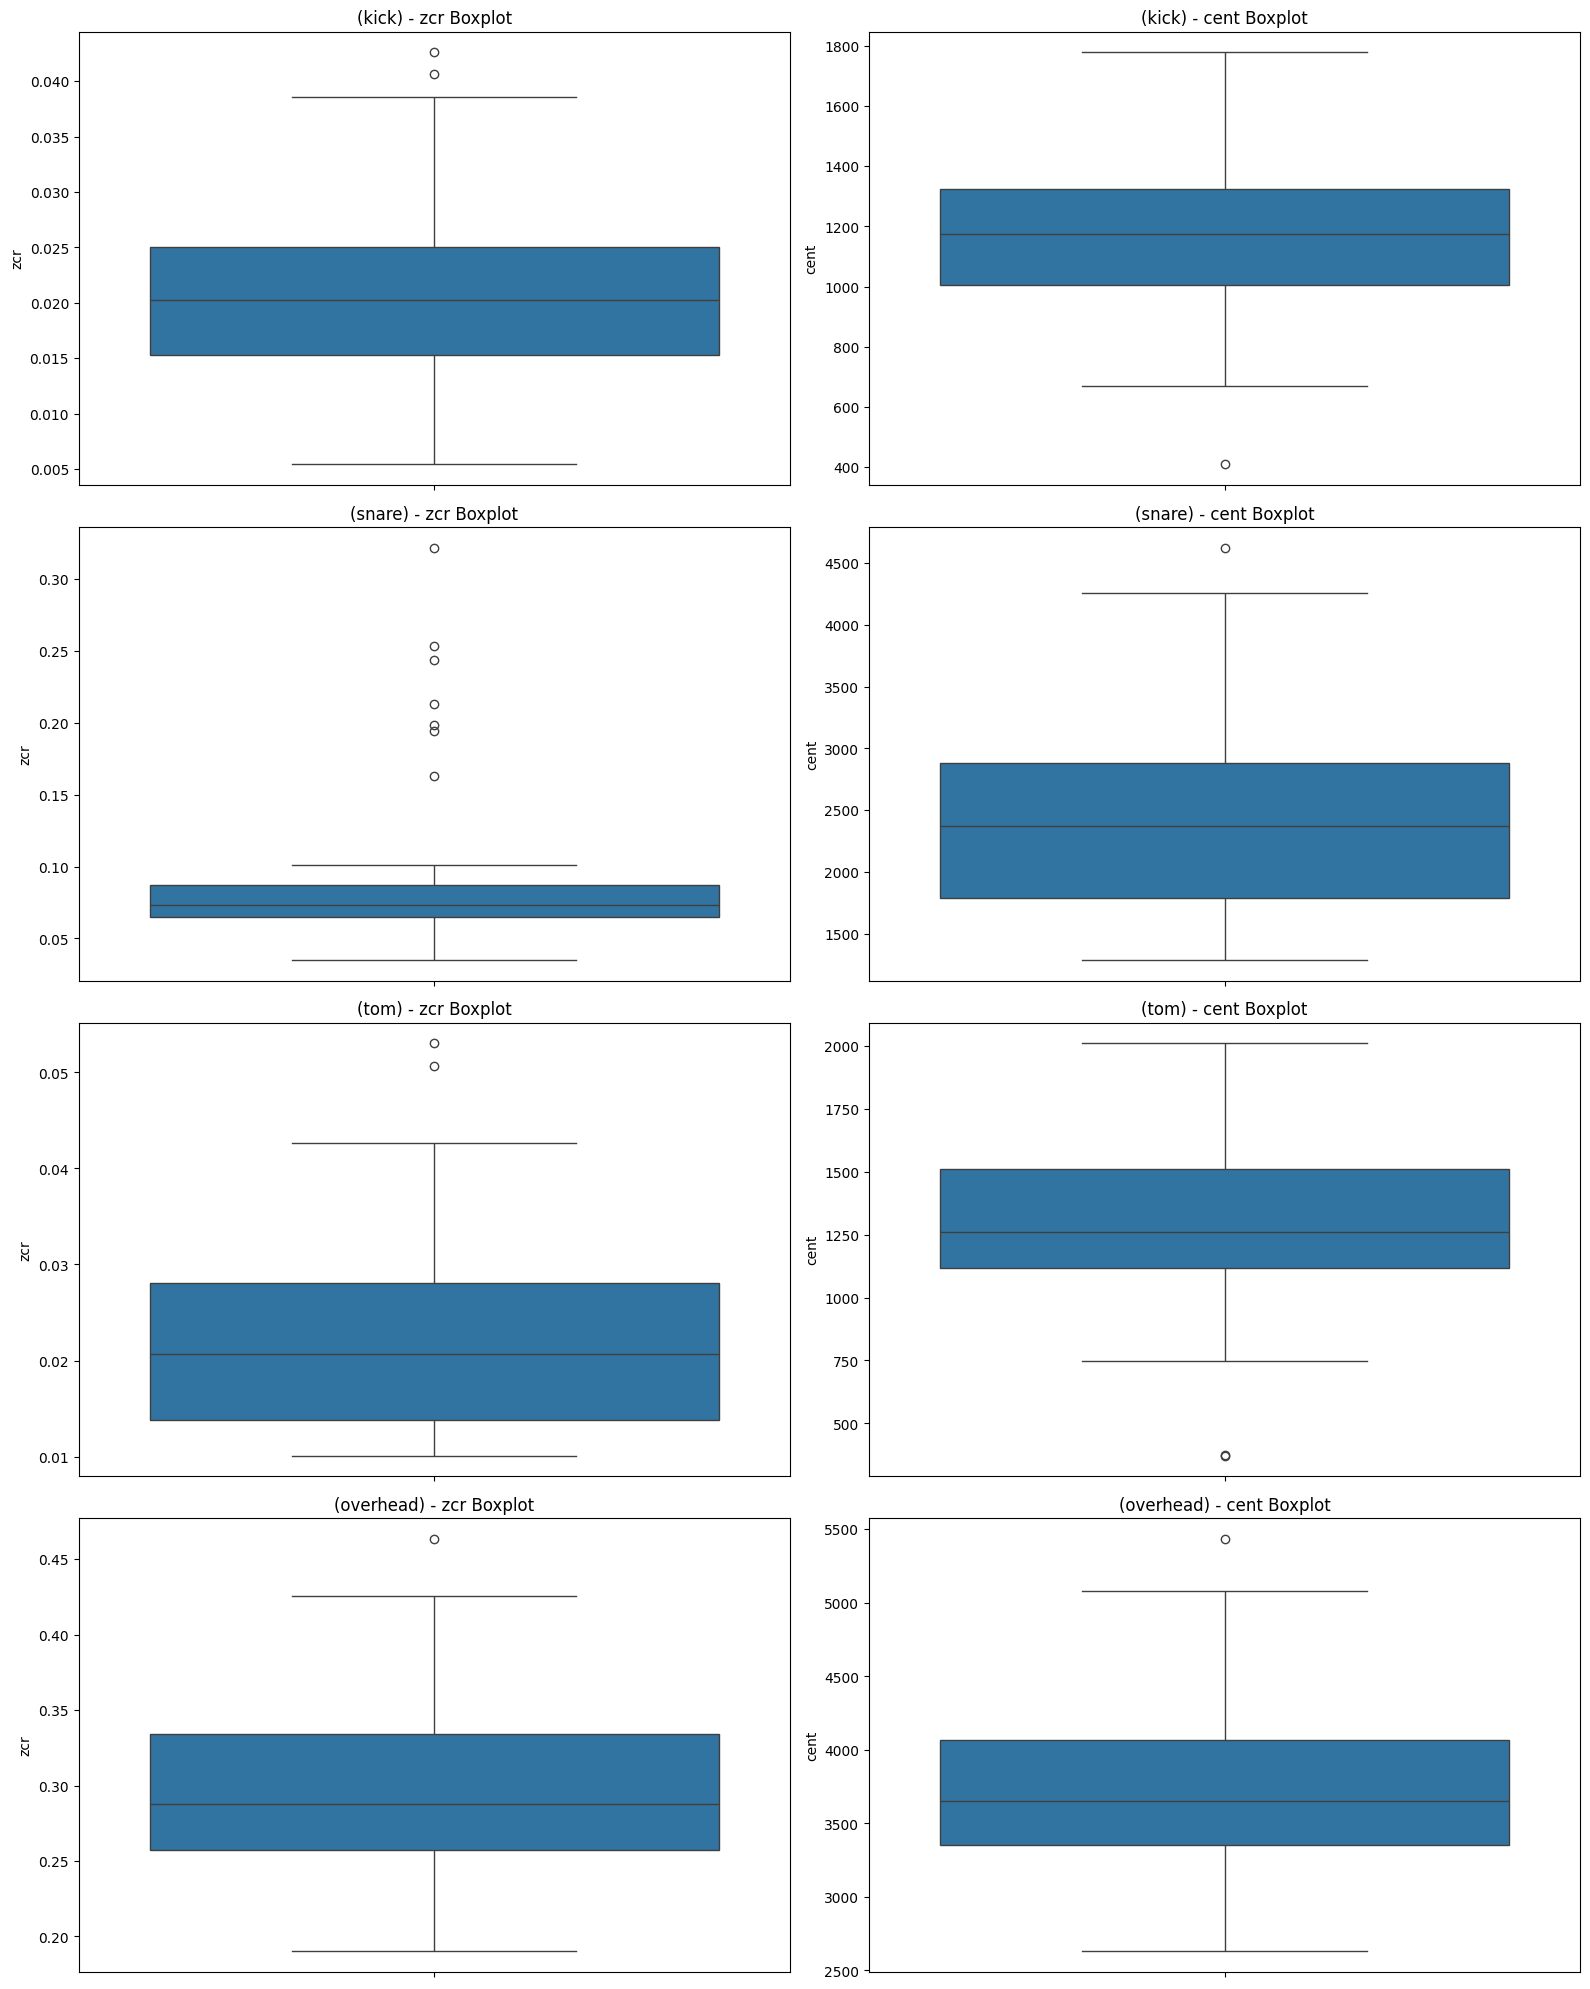

In [ ]:
classes = ["kick", "snare", "tom", "overhead"]
target = ["zcr", "cent"]

fig, ax = plt.subplots(nrows=4, ncols=2, figsize=(16, 20))

for row, cls in enumerate(classes):
    df_class = df[df["label"] == cls]

    for col, feature in enumerate(target):
        sns.boxplot(
            data=df_class,
            y=feature,
            ax=ax[row, col]
        )

        median_value = df_class[feature].median()

        ax[row, col].set_title(
            f"({cls}) - {feature} Boxplot"
        )
        ax[row, col].set_xlabel("")
        ax[row, col].set_ylabel(feature)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/2 - Side Projects/DrumRecognizer/imgs/boxplot.png')
plt.show()

##**Covariance Matrix**

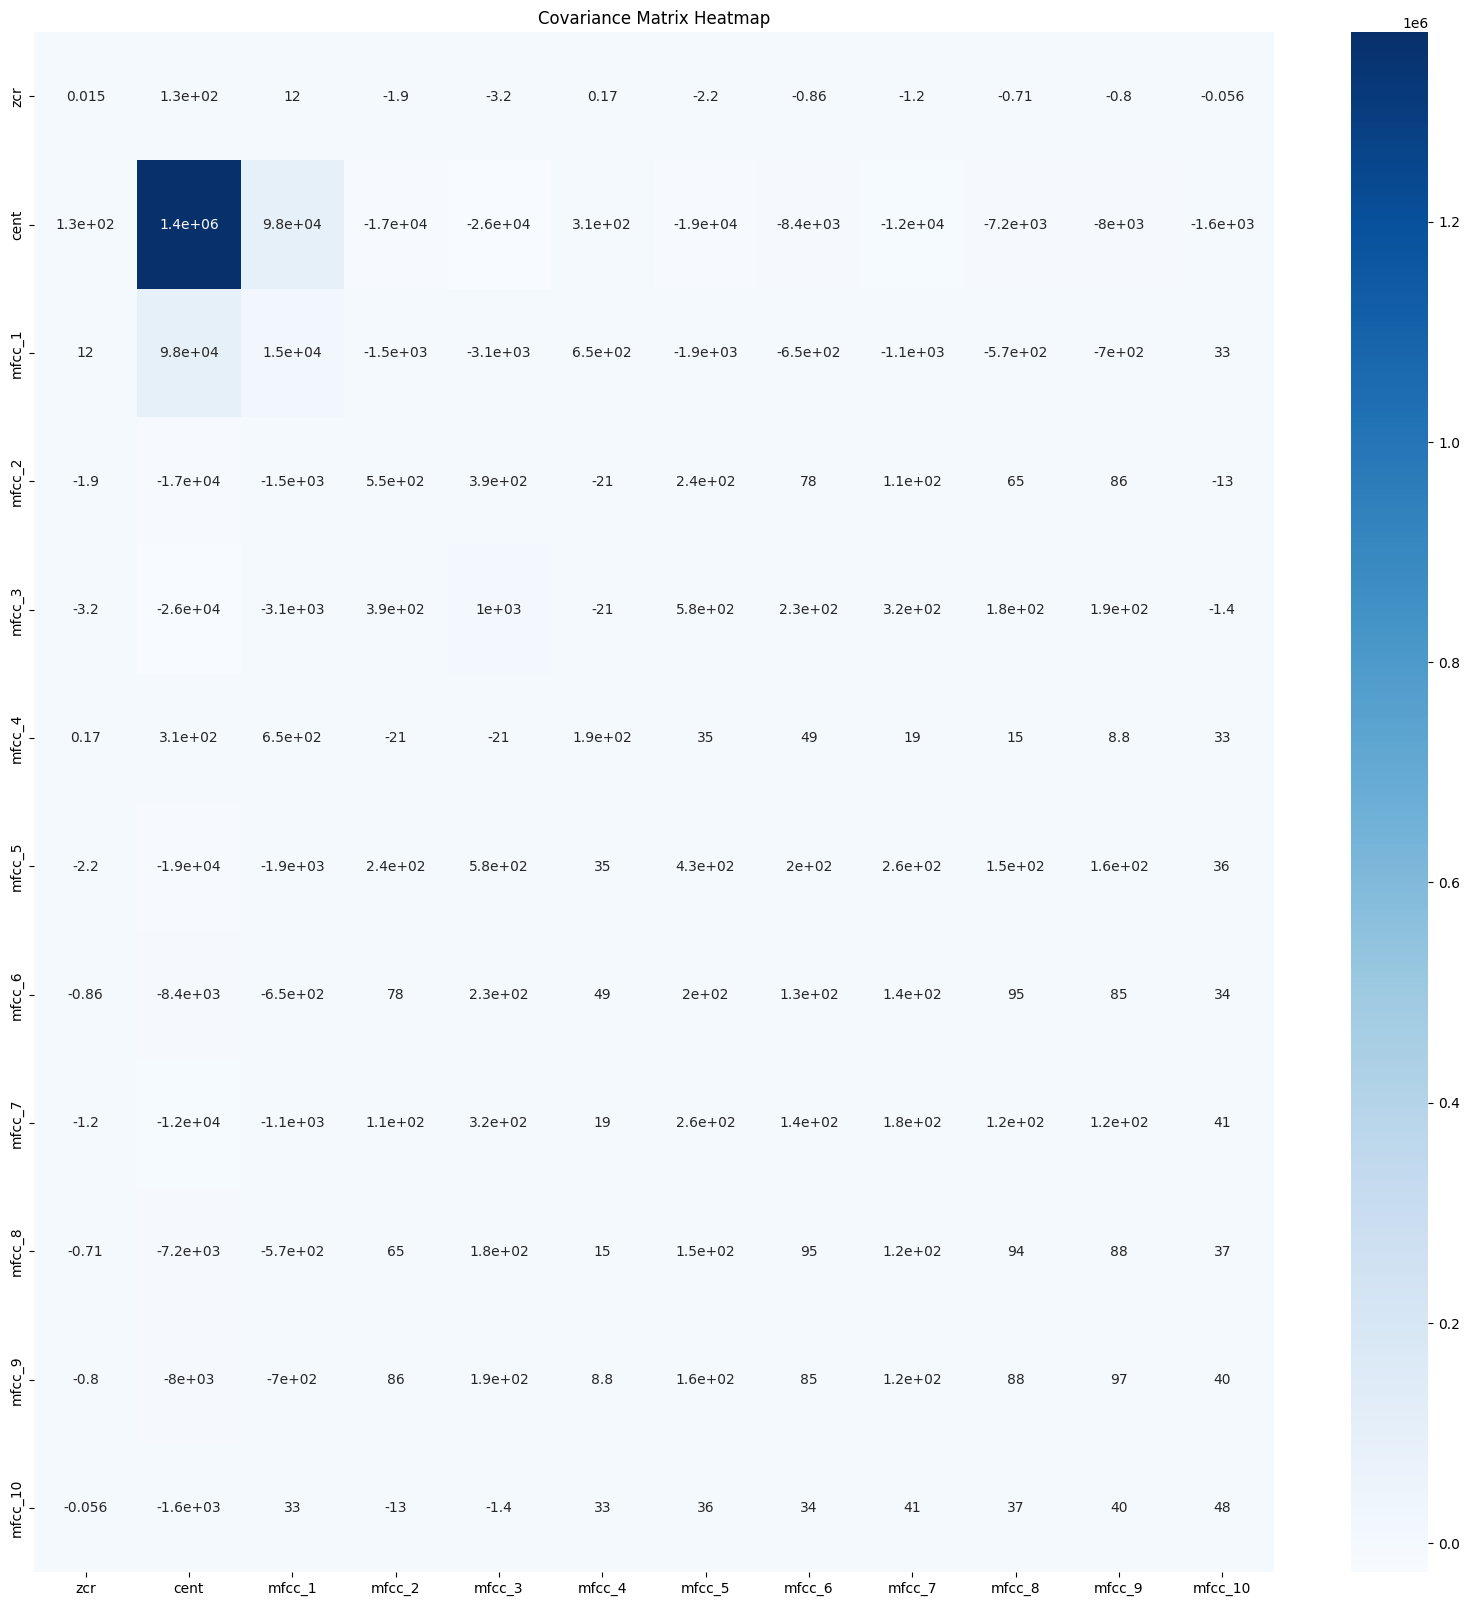

In [ ]:
cov_matrix = df[num_vars].cov()
plt.figure(figsize=(20, 20))
sns.heatmap(cov_matrix, annot=True, cmap='Blues')

plt.title('Covariance Matrix Heatmap')
plt.savefig("/content/drive/MyDrive/2 - Side Projects/DrumRecognizer/imgs/covariance_matrix.png")
plt.show()

##**Correlation Matrix**

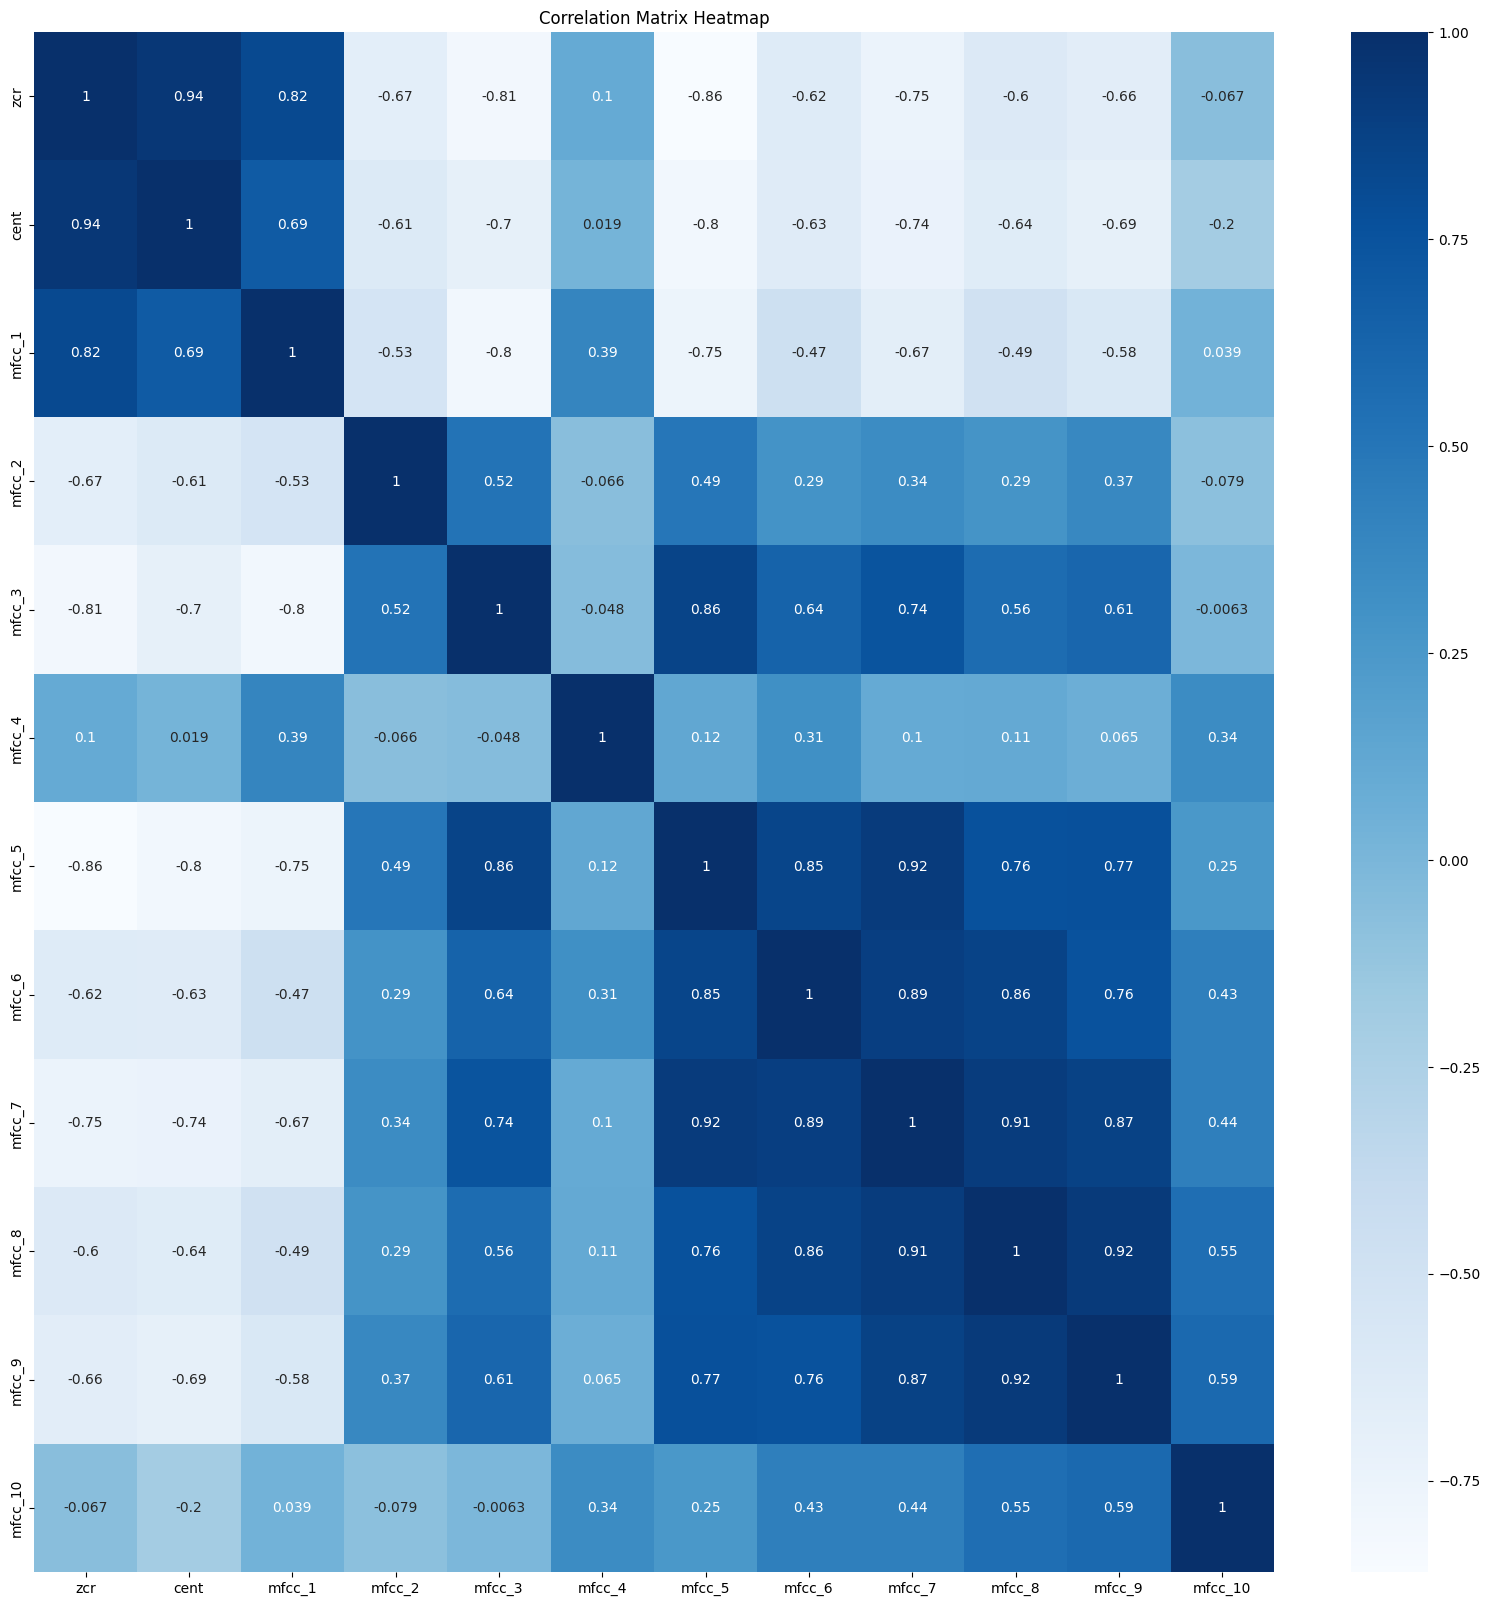

In [ ]:
corrmat = df[num_vars].corr()
plt.figure(figsize=(20,20))
sns.heatmap(corrmat, cmap="Blues",annot=True);
plt.title('Correlation Matrix Heatmap')
plt.savefig("/content/drive/MyDrive/2 - Side Projects/DrumRecognizer/imgs/correlation_matrix.png")
plt.show()

##**Scatter Plot**

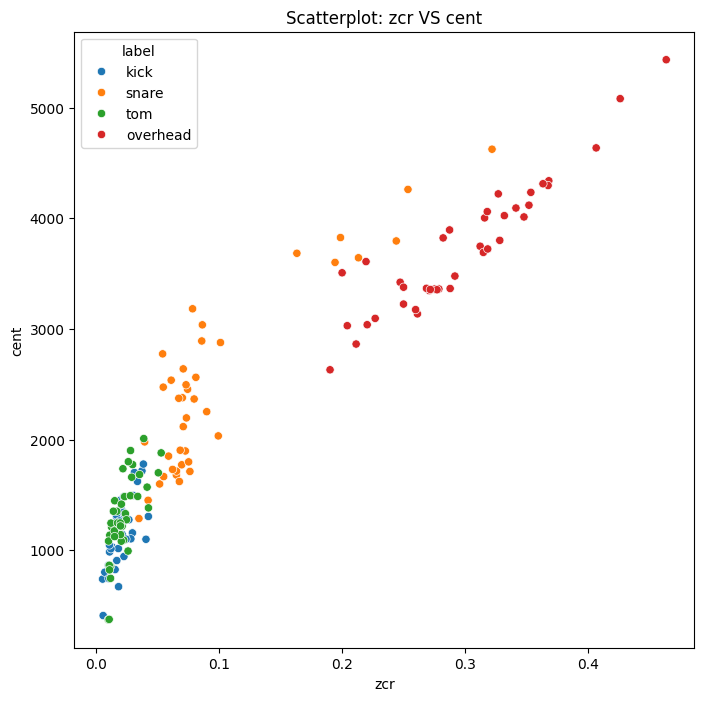

In [ ]:
plt.figure(figsize=(8, 8))
sns.scatterplot(data=df, x='zcr', y='cent', hue='label')
plt.title("Scatterplot: zcr VS cent")
plt.savefig("/content/drive/MyDrive/2 - Side Projects/DrumRecognizer/imgs/scatter/scatter_zcr_vs_cent.png")

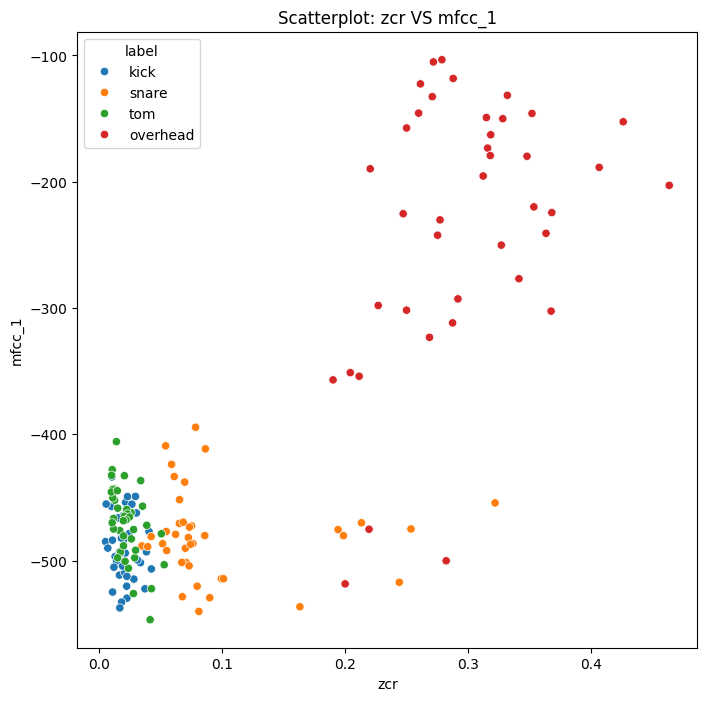

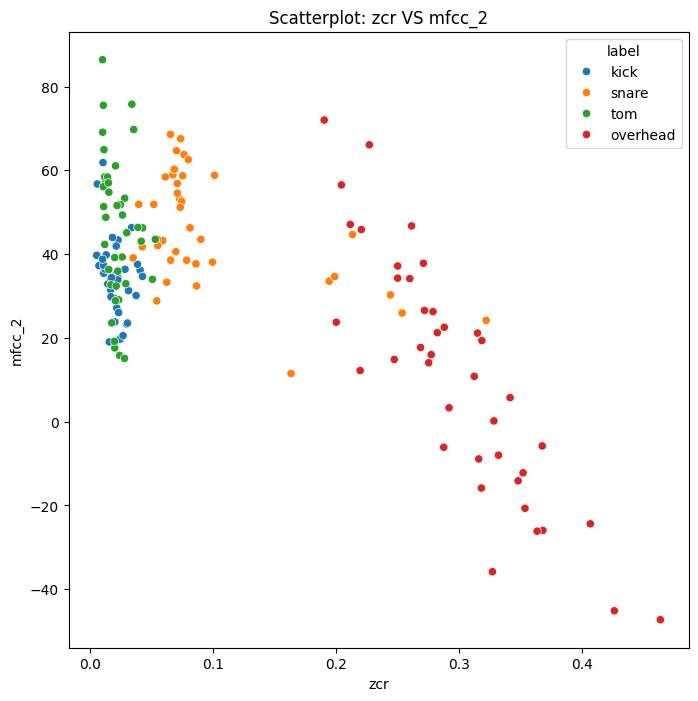

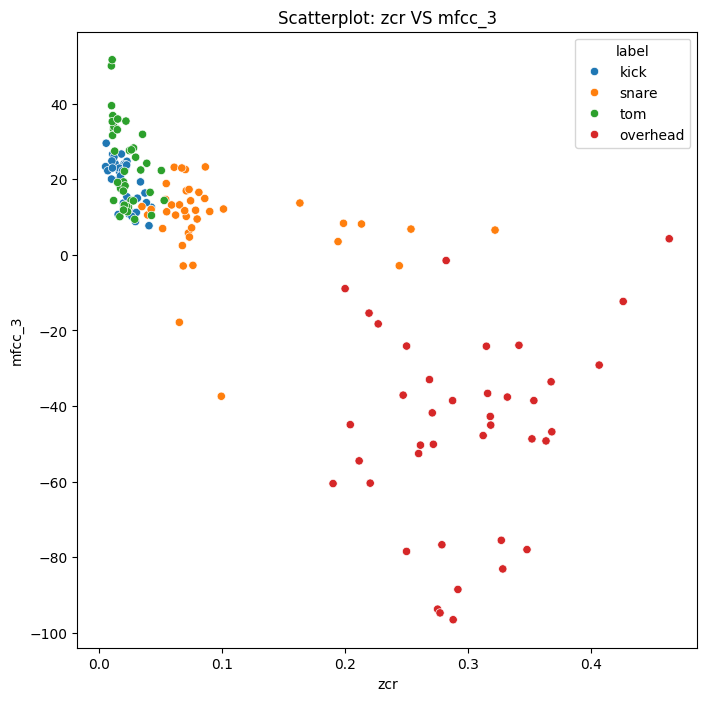

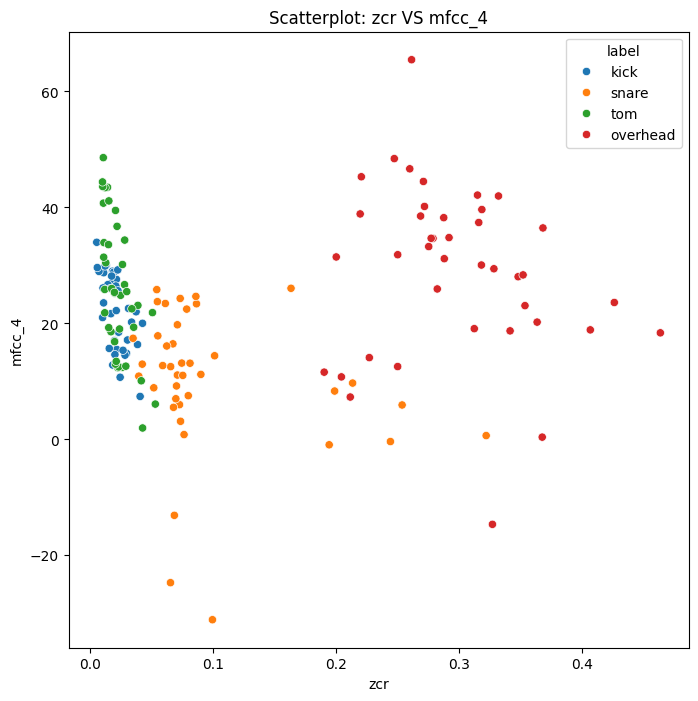

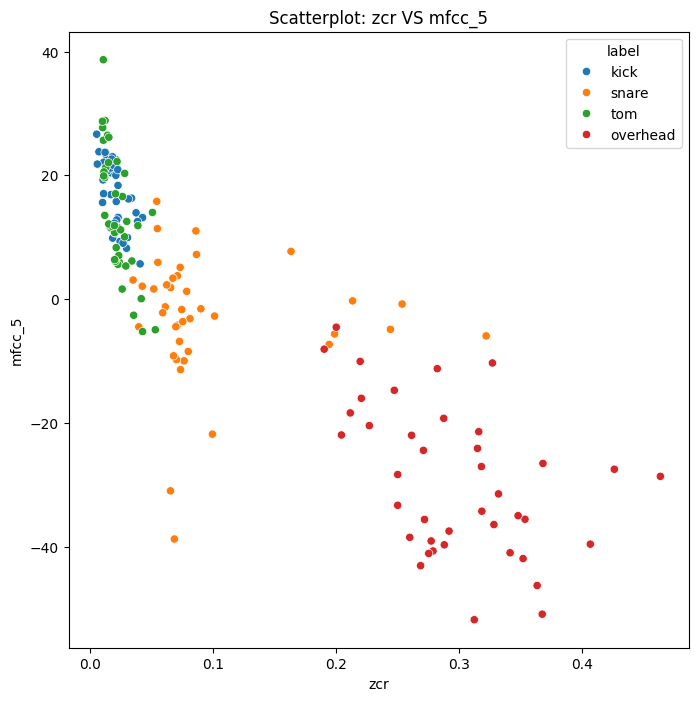

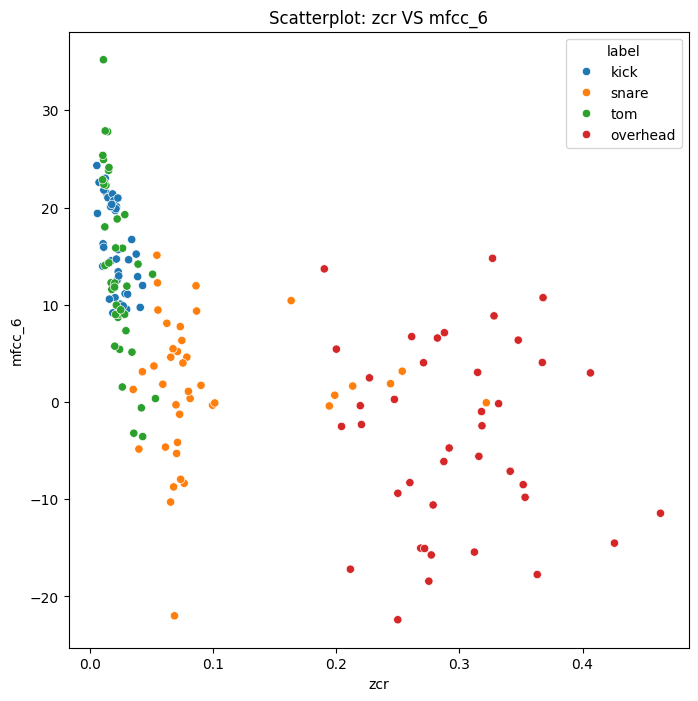

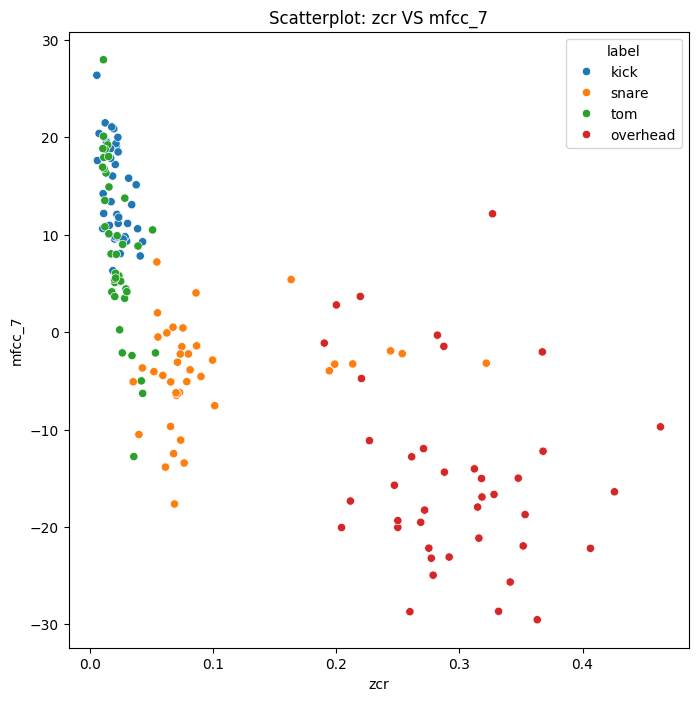

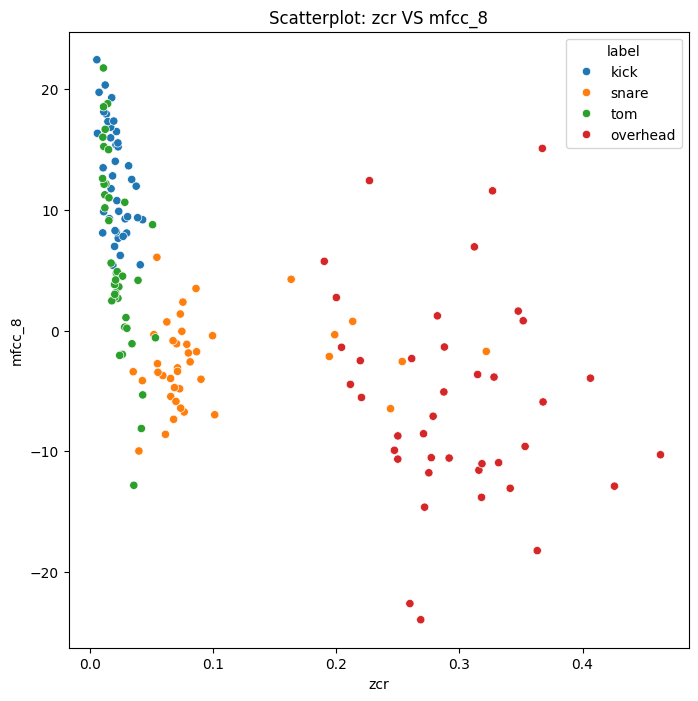

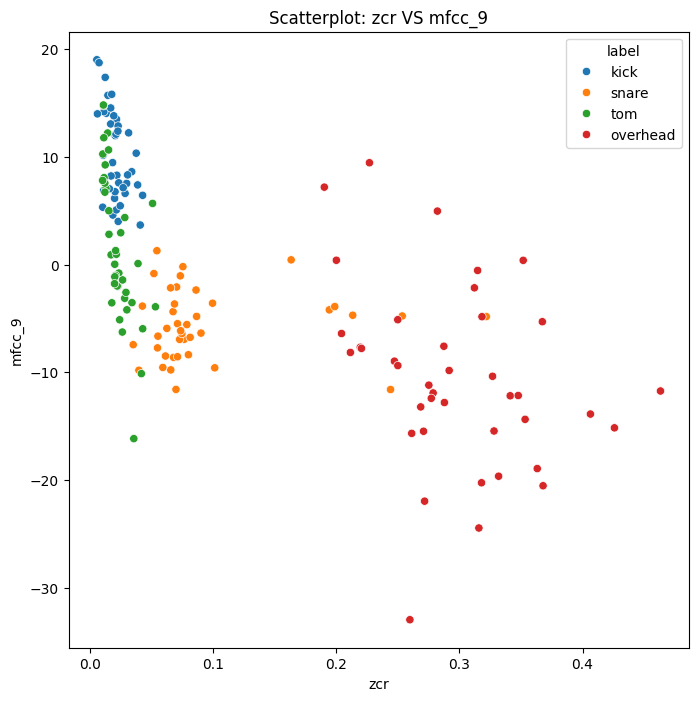

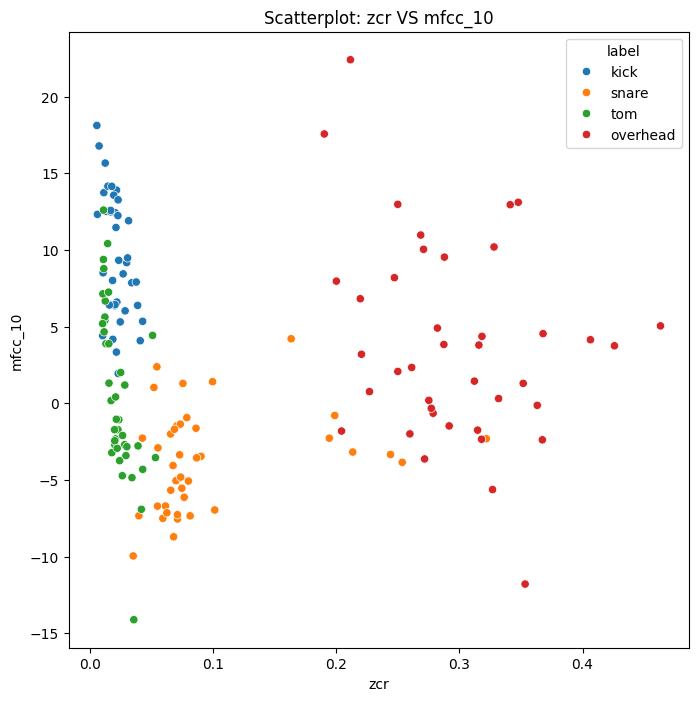

In [ ]:
for i in range(n_mfcc):
  plt.figure(figsize=(8,8))
  sns.scatterplot(data=df, x="zcr", y=f"mfcc_{i+1}", hue="label")
  plt.title(f"Scatterplot: zcr VS mfcc_{i+1}")
  plt.savefig(f"/content/drive/MyDrive/2 - Side Projects/DrumRecognizer/imgs/scatter/scatter_zcr_vs_mfcc_{i+1}.png")



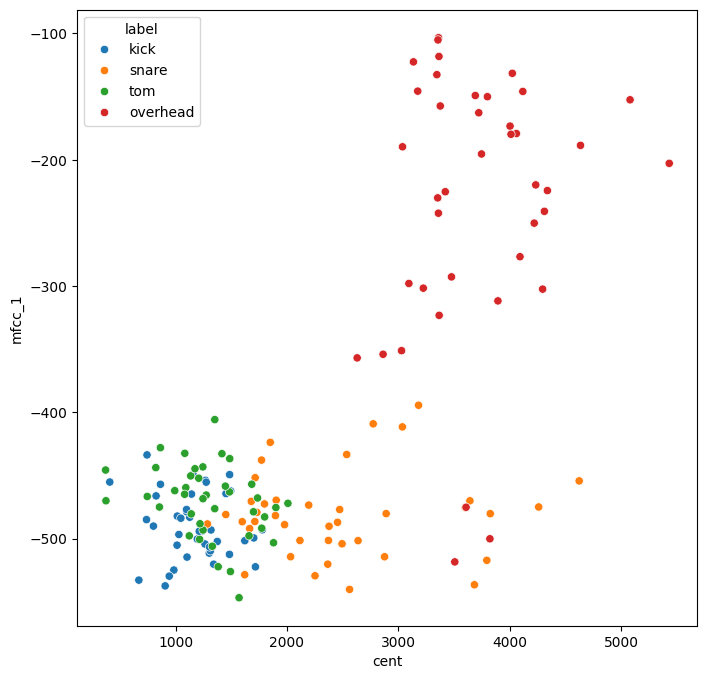

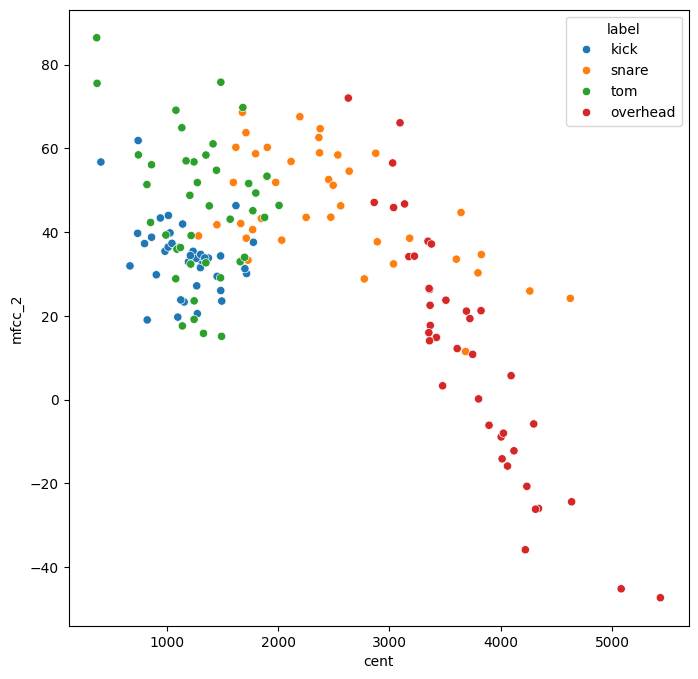

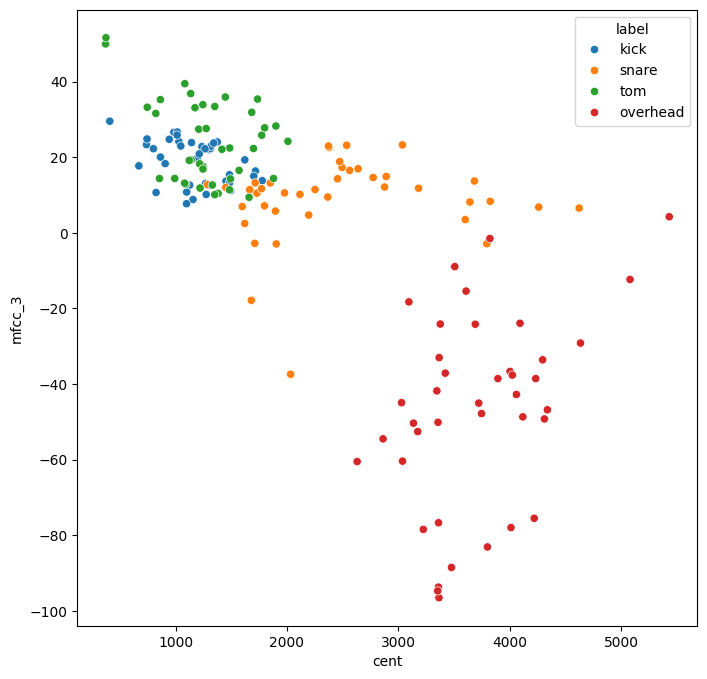

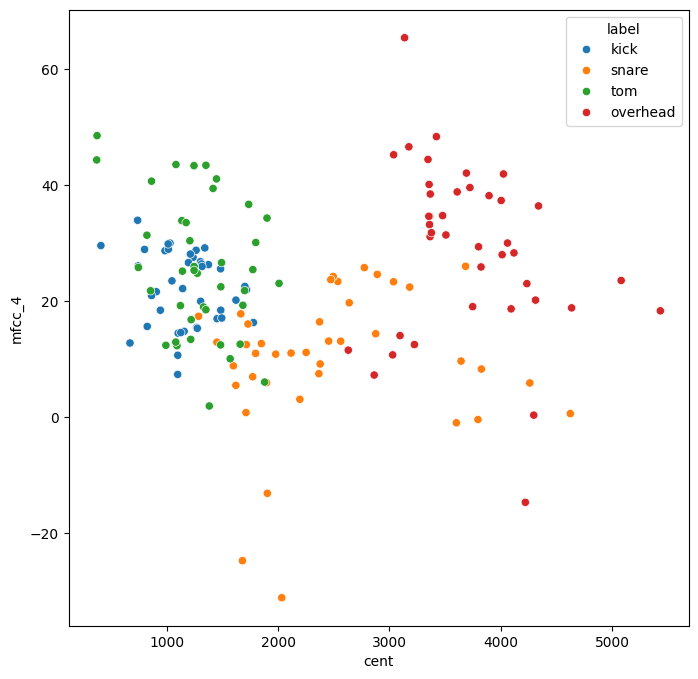

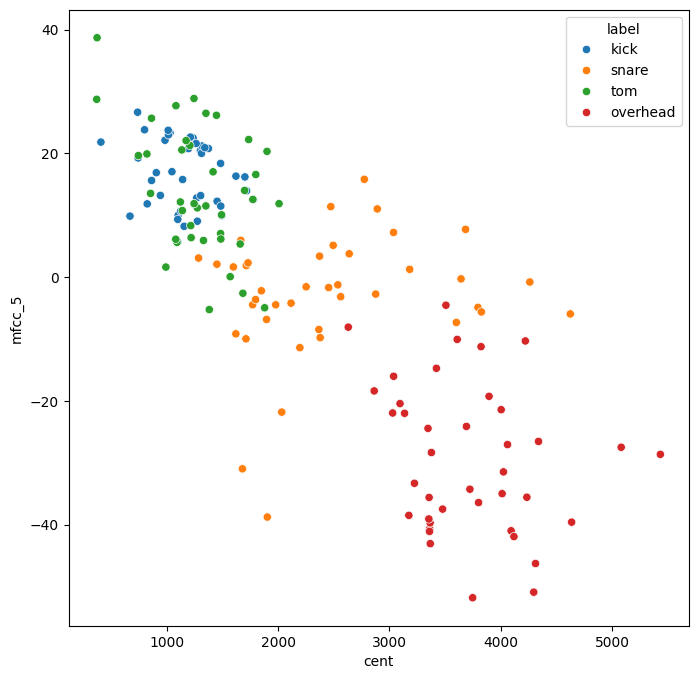

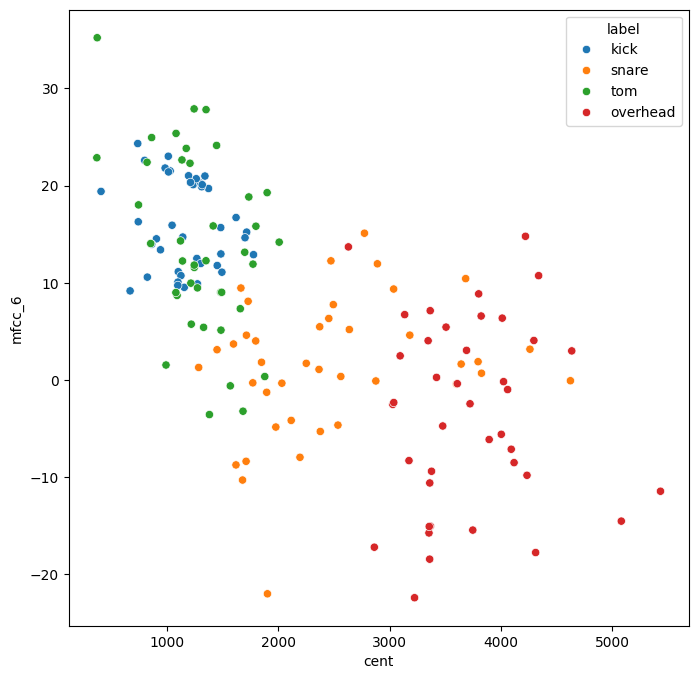

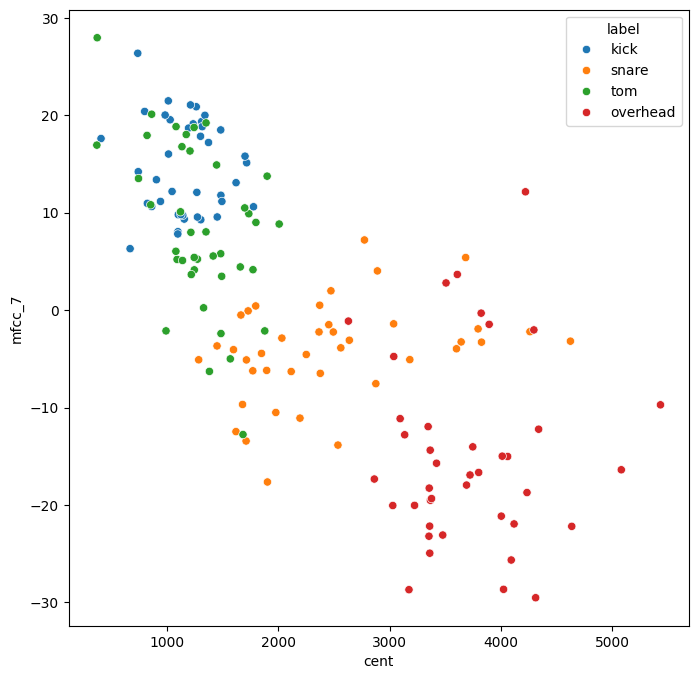

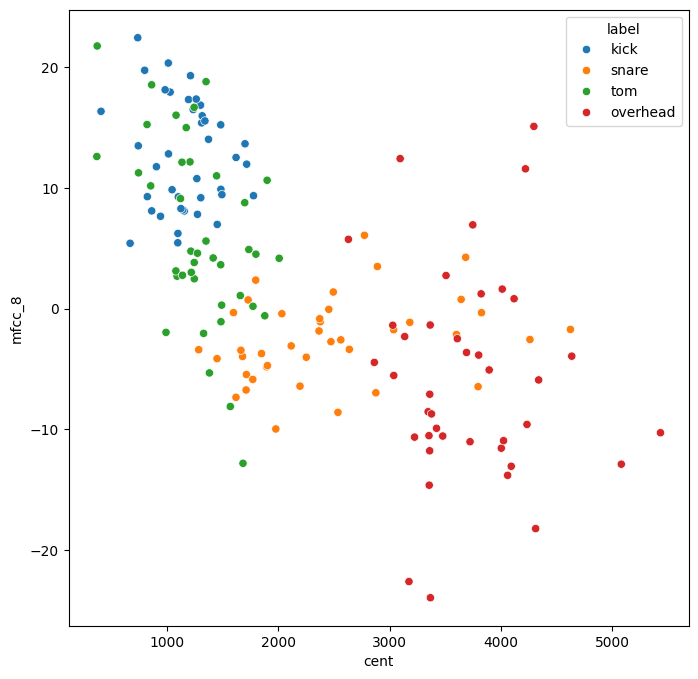

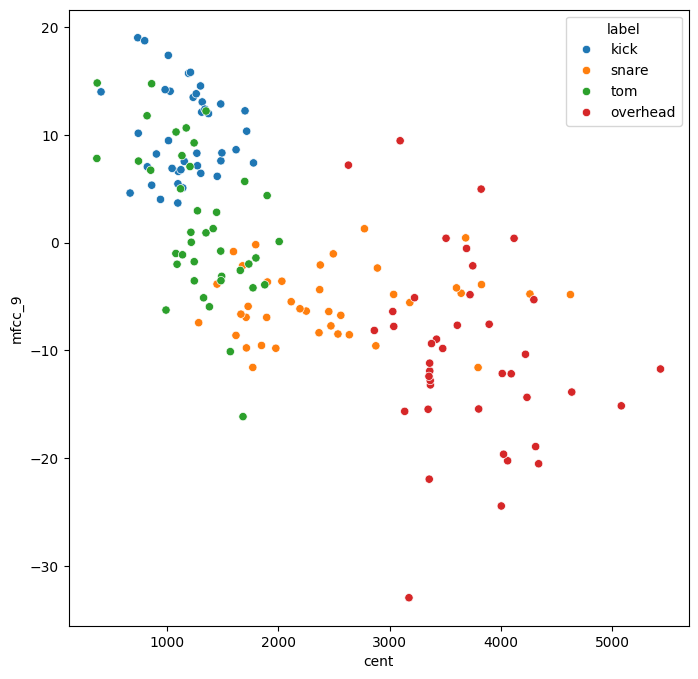

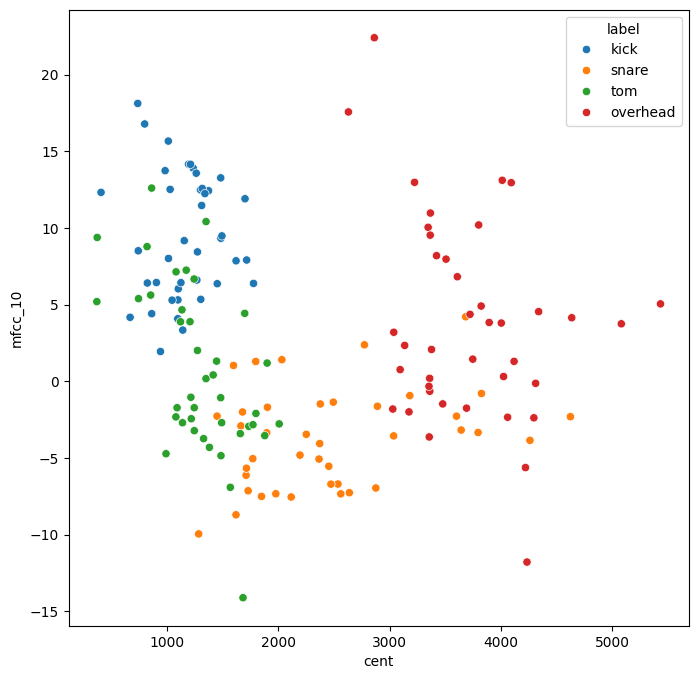

In [ ]:
for i in range(n_mfcc):
  plt.figure(figsize=(8,8))
  sns.scatterplot(data=df, x="cent", y=f"mfcc_{i+1}", hue="label")
  plt.savefig(f"/content/drive/MyDrive/2 - Side Projects/DrumRecognizer/imgs/scatter/scatter_cent_vs_mfcc_{i+1}.png")

plt.show()

##**Pair Scatter**

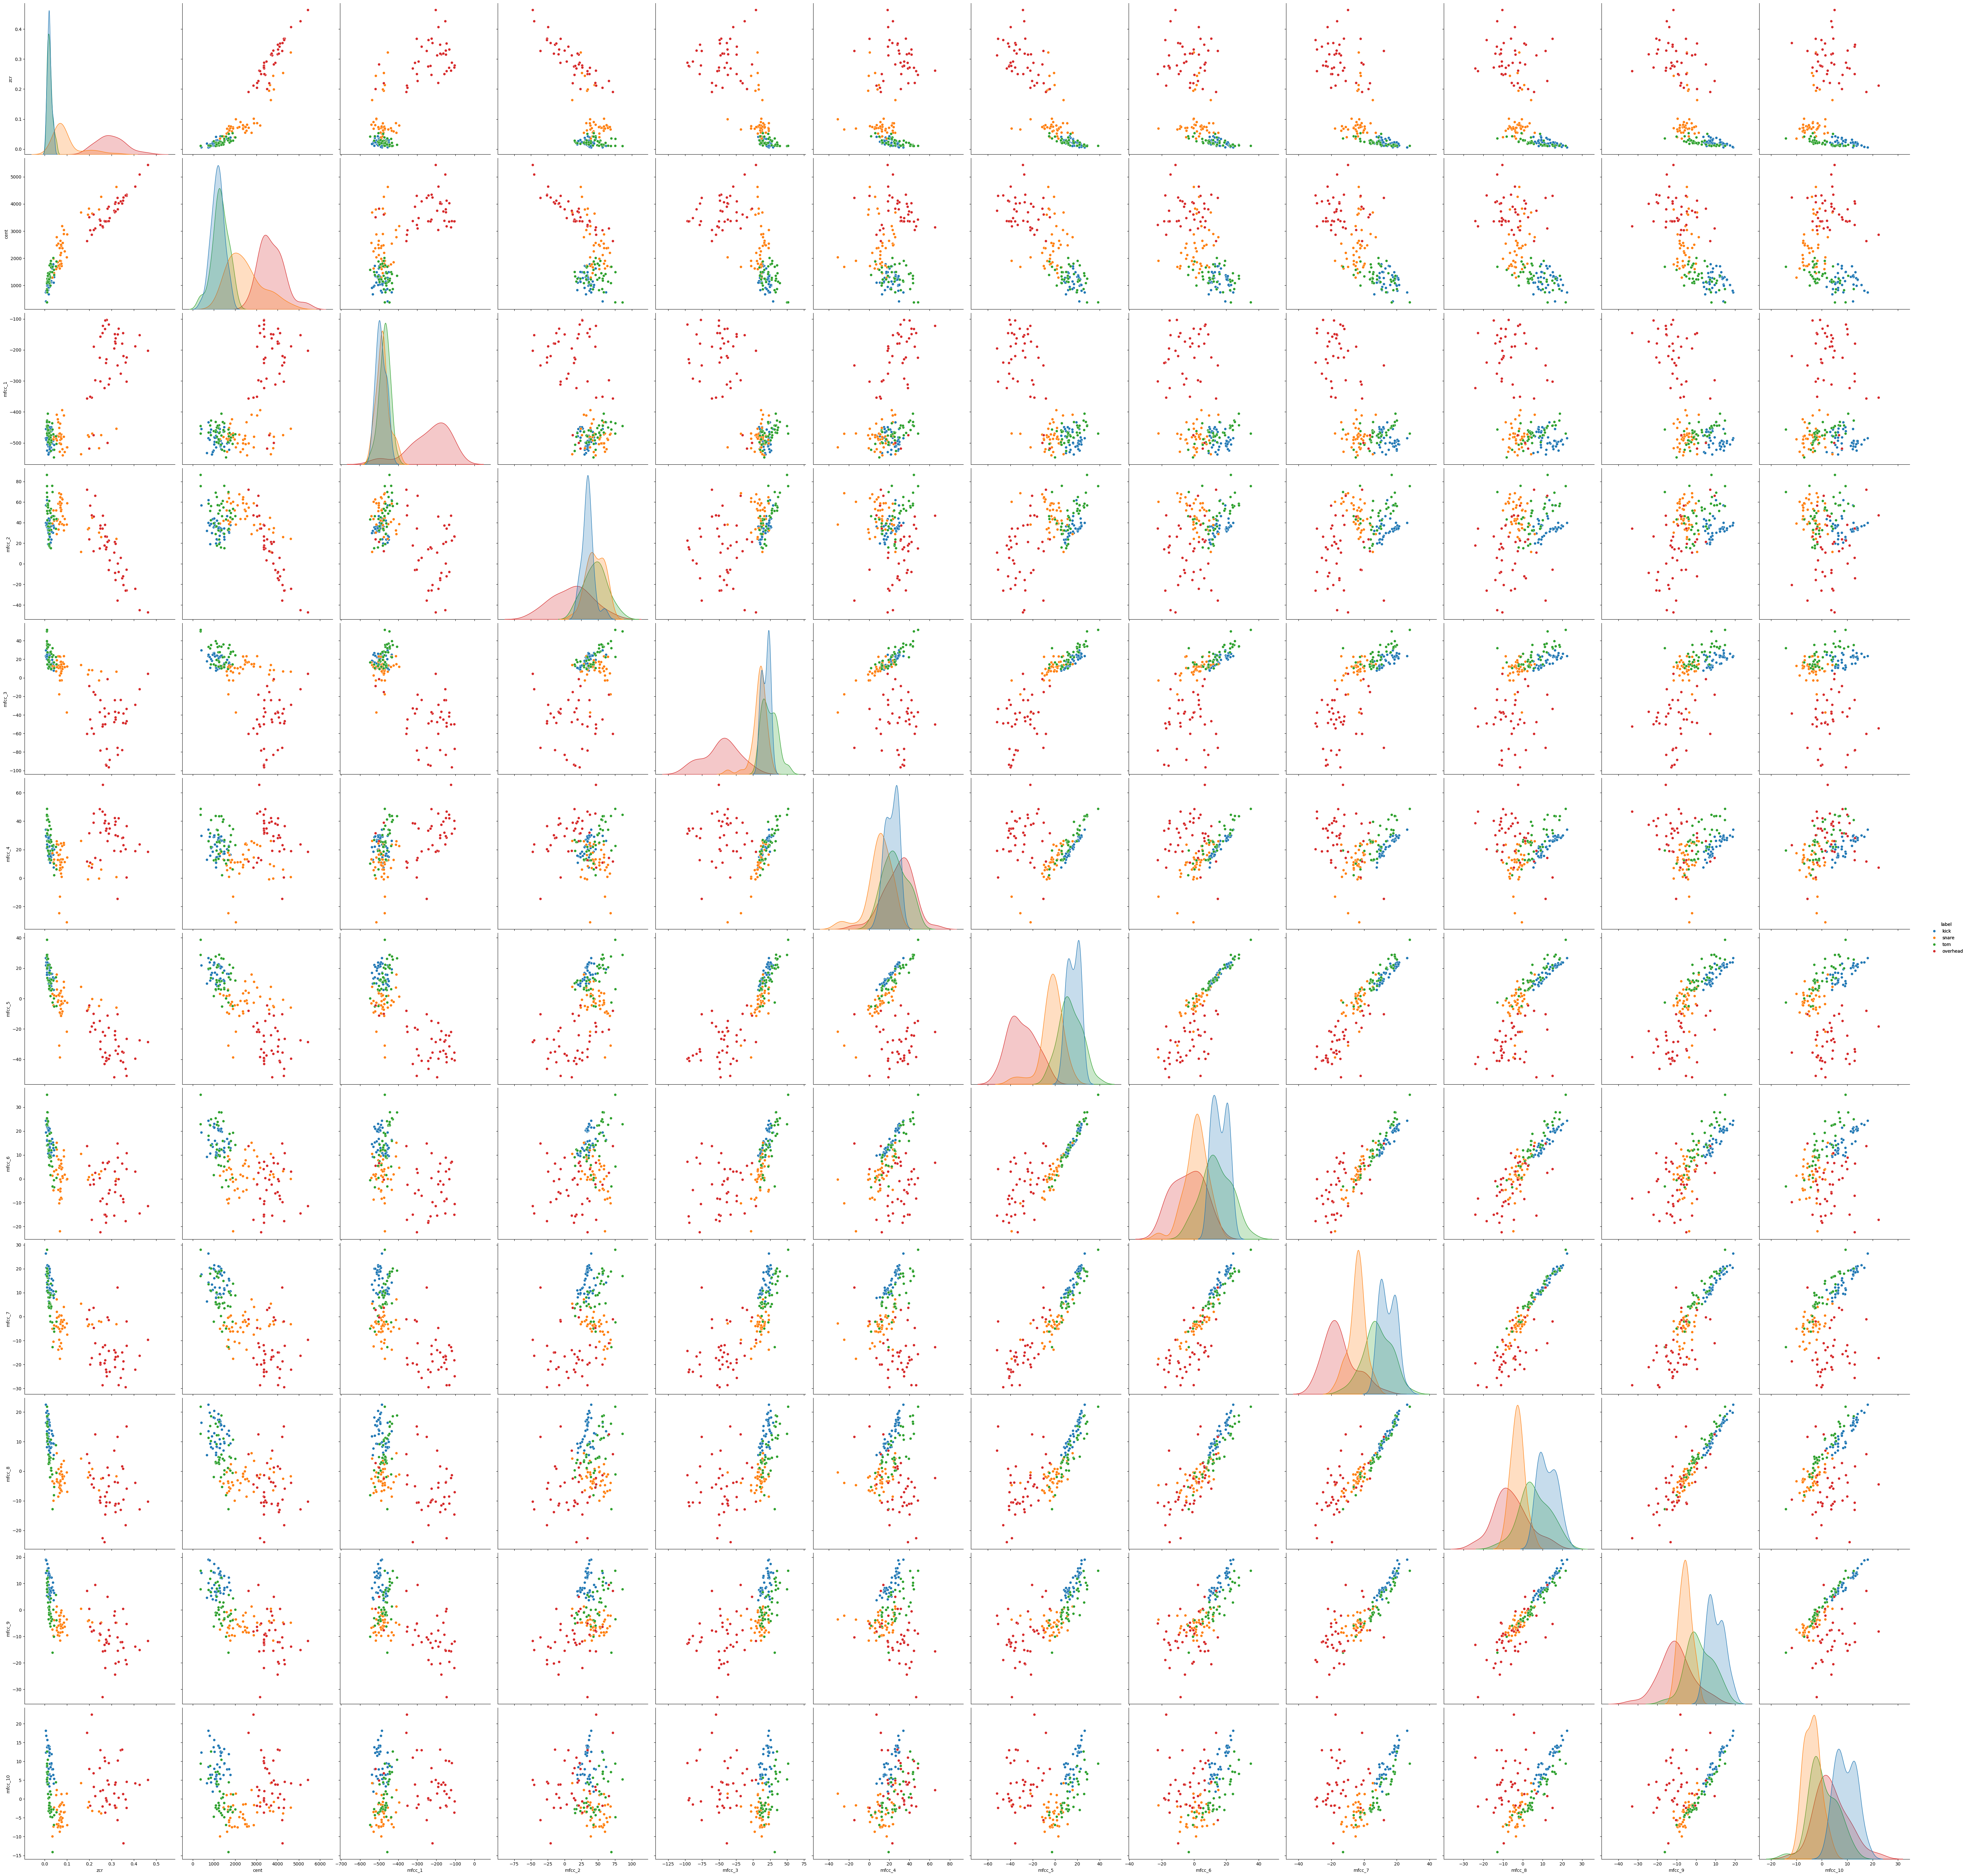

In [ ]:
vars_to_plot = ['zcr', 'cent']
for i in range(n_mfcc):
  vars_to_plot.append(f"mfcc_{i+1}")
sns.pairplot(df, x_vars=vars_to_plot, y_vars=vars_to_plot, hue="label", height=5).add_legend()